### Importación de Librerías y Configuración del Entorno

In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
    auc,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    f1_score,
)
import joblib

# Permitir importar desde src/
BASE_DIR = Path("..")
sys.path.append(str(BASE_DIR))

from src.model import Autoencoder

# Configuración gráfica
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚡ Dispositivo para inferencia: {device}")

PROCESSED_DATA_PATH = BASE_DIR / "data" / "processed"
MODELS_DIR = BASE_DIR / "models"

⚡ Dispositivo para inferencia: cpu


In [3]:
# ---------------------------------------------------------
# 1. Cargar datos procesados y sus etiquetas reales
# ---------------------------------------------------------
X_test = np.load(PROCESSED_DATA_PATH / "X_test.npy")
y_test = np.load(PROCESSED_DATA_PATH / "y_test.npy")

X_val = np.load(PROCESSED_DATA_PATH / "X_val.npy")
y_val = np.load(PROCESSED_DATA_PATH / "y_val.npy")

print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Distribución de etiquetas y_test -> Lícitas (0): {(y_test == 0).sum()} | Ilícitas (1): {(y_test == 1).sum()}")

Dimensiones de X_test: (57109, 30)
Distribución de etiquetas y_test -> Lícitas (0): 56863 | Ilícitas (1): 246


In [4]:
# ---------------------------------------------------------
# 2. Cargar la arquitectura e hiperparámetros del modelo
# ---------------------------------------------------------
INPUT_DIM = X_test.shape[1]

checkpoint = torch.load(MODELS_DIR / "autoencoder_creditcard.pth", map_location=device)
model = Autoencoder(
    input_dim=INPUT_DIM,
    bottleneck_dim=checkpoint.get("bottleneck_dim", 14),
)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)

model.eval()
print("✅ Modelo de Credit Card cargado exitosamente en modo evaluación.")


✅ Modelo de Credit Card cargado exitosamente en modo evaluación.


In [5]:
# ---------------------------------------------------------
# 3. Inferencia y Cálculo del Error de Reconstrucción (MSE)
# ---------------------------------------------------------
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)

with torch.no_grad():
    X_test_reconstructed = model(X_test_tensor).cpu().numpy()
    X_val_reconstructed = model(X_val_tensor).cpu().numpy()

# Error Cuadrático Medio (MSE) por muestra en el espacio de características escalado
reconstruction_errors_test = np.mean(np.square(X_test - X_test_reconstructed), axis=1)
reconstruction_errors_val = np.mean(np.square(X_val - X_val_reconstructed), axis=1)

print(f"\nError de Reconstrucción Promedio Test: {reconstruction_errors_test.mean():.6f}")
print(f"  └─ Promedio en Lícitas (Clase 0) Test: {reconstruction_errors_test[y_test == 0].mean():.6f}")
print(f"  └─ Promedio en Ilícitas (Clase 1) Test: {reconstruction_errors_test[y_test == 1].mean():.6f}")
print(f"Error de Reconstrucción Promedio Val:  {reconstruction_errors_val.mean():.6f}")
print(f"  └─ Promedio en Lícitas (Clase 0) Val:  {reconstruction_errors_val[y_val == 0].mean():.6f}")
print(f"  └─ Promedio en Ilícitas (Clase 1) Val:  {reconstruction_errors_val[y_val == 1].mean():.6f}")



Error de Reconstrucción Promedio Test: 0.172564
  └─ Promedio en Lícitas (Clase 0) Test: 0.109243
  └─ Promedio en Ilícitas (Clase 1) Test: 14.809408
Error de Reconstrucción Promedio Val:  0.174703
  └─ Promedio en Lícitas (Clase 0) Val:  0.107316
  └─ Promedio en Ilícitas (Clase 1) Val:  15.751208


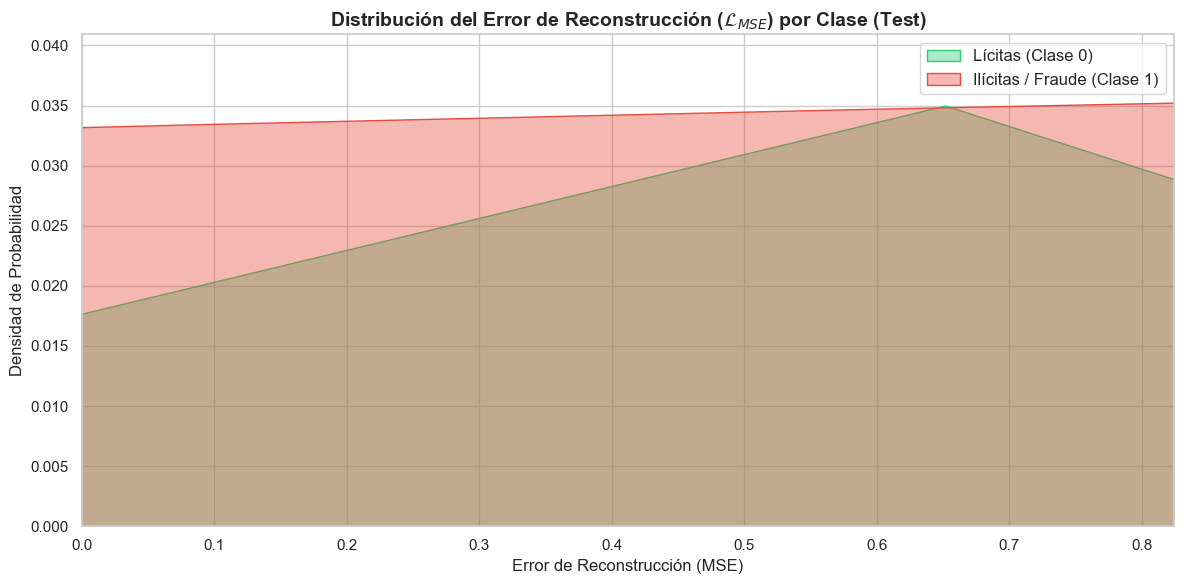

In [6]:
# ---------------------------------------------------------
# 4. Gráfico de Densidad (KDE) de Errores por Clase
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

sns.kdeplot(reconstruction_errors_test[y_test == 0], label="Lícitas (Clase 0)", color="#2ecc71", fill=True, alpha=0.4, ax=ax)
sns.kdeplot(reconstruction_errors_test[y_test == 1], label="Ilícitas / Fraude (Clase 1)", color="#e74c3c", fill=True, alpha=0.4, ax=ax)

ax.set_title("Distribución del Error de Reconstrucción ($\mathcal{L}_{MSE}$) por Clase (Test)", fontsize=14, fontweight='bold')
ax.set_xlabel("Error de Reconstrucción (MSE)", fontsize=12)
ax.set_ylabel("Densidad de Probabilidad", fontsize=12)
ax.set_xlim([0, np.percentile(reconstruction_errors_test, 99)])  # Acotar outliers extremos para mejor vista
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


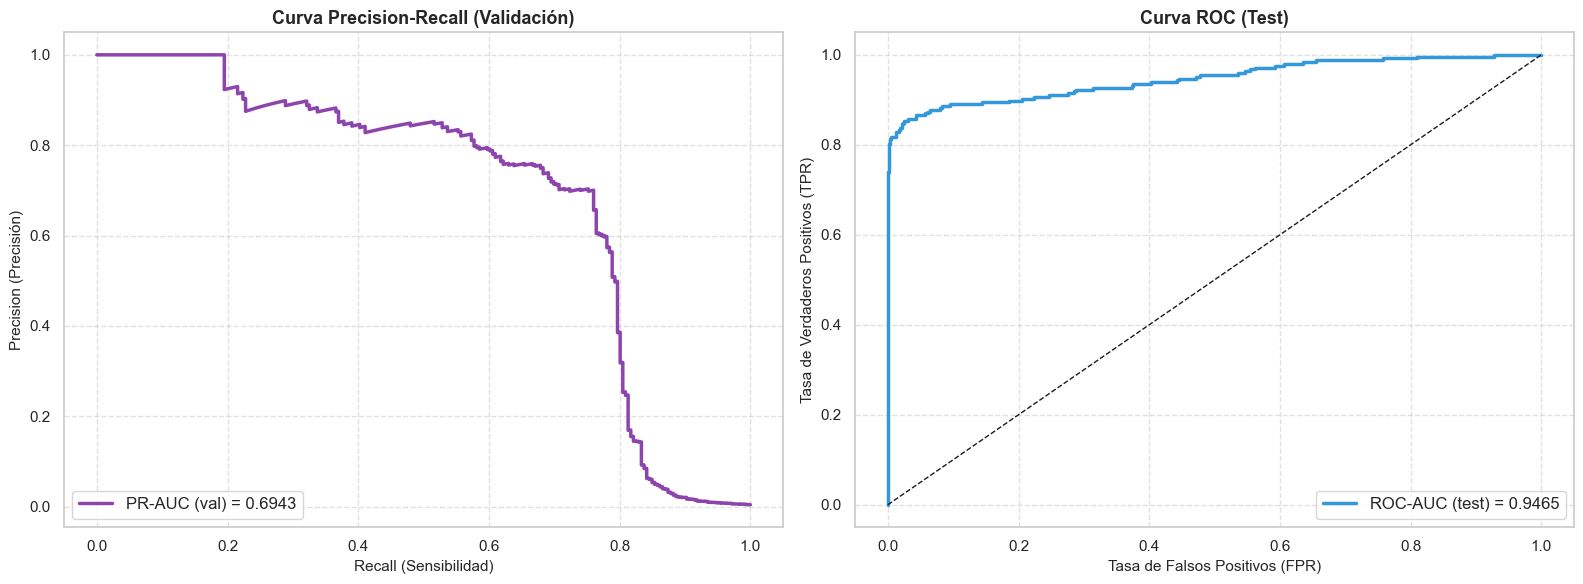

In [7]:
# ---------------------------------------------------------
# 5. Evaluación de Curvas PR (Val) y ROC (Test)
# ---------------------------------------------------------
precision_v, recall_v, thresholds_v = precision_recall_curve(y_val, reconstruction_errors_val)
pr_auc_val = auc(recall_v, precision_v)

fpr, tpr, _ = roc_curve(y_test, reconstruction_errors_test)
roc_auc_test = roc_auc_score(y_test, reconstruction_errors_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Curva PR (Validación)
axes[0].plot(recall_v, precision_v, color='#8e44ad', lw=2.5, label=f'PR-AUC (val) = {pr_auc_val:.4f}')
axes[0].set_title("Curva Precision-Recall (Validación)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Recall (Sensibilidad)", fontsize=11)
axes[0].set_ylabel("Precision (Precisión)", fontsize=11)
axes[0].legend(loc="lower left", fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Curva ROC (Test)
axes[1].plot(fpr, tpr, color='#3498db', lw=2.5, label=f'ROC-AUC (test) = {roc_auc_test:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_title("Curva ROC (Test)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Tasa de Falsos Positivos (FPR)", fontsize=11)
axes[1].set_ylabel("Tasa de Verdaderos Positivos (TPR)", fontsize=11)
axes[1].legend(loc="lower right", fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


🎯 Umbral Óptimo Seleccionado (\tau) en VALIDACIÓN: 2.410458
   ├─ Precision (val) en el umbral: 0.7004
   ├─ Recall    (val) en el umbral: 0.7602
   └─ F1-Score Máximo (val):        0.7290


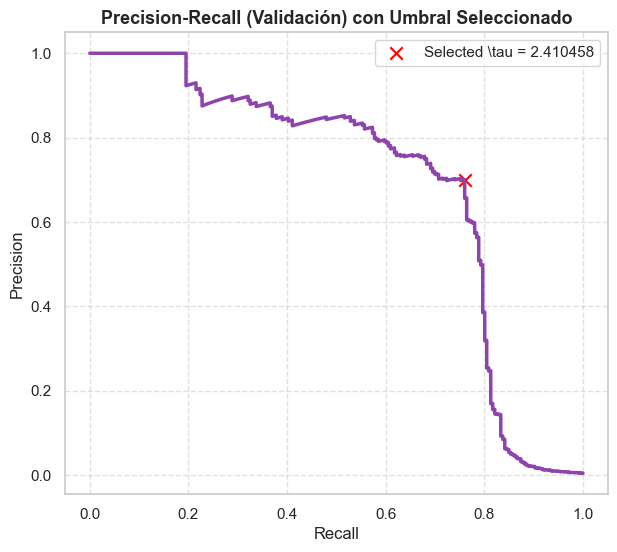

In [8]:
# ---------------------------------------------------------
# 6. Selección del Umbral Óptimo (\tau) mediante F1-Score en VALIDACIÓN
# ---------------------------------------------------------
precision_valid = precision_v[1:]
recall_valid = recall_v[1:]
f1_scores = 2 * (precision_valid * recall_valid) / (precision_valid + recall_valid + 1e-10)

best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds_v[best_idx]
best_f1 = f1_scores[best_idx]

print(f"\n🎯 Umbral Óptimo Seleccionado (\\tau) en VALIDACIÓN: {optimal_threshold:.6f}")
print(f"   ├─ Precision (val) en el umbral: {precision_valid[best_idx]:.4f}")
print(f"   ├─ Recall    (val) en el umbral: {recall_valid[best_idx]:.4f}")
print(f"   └─ F1-Score Máximo (val):        {best_f1:.4f}")

# Gráfico PR de validación con marcador en el umbral óptimo
point_recall = recall_v[best_idx + 1]
point_precision = precision_v[best_idx + 1]

plt.figure(figsize=(7, 6))
plt.plot(recall_v, precision_v, color='#8e44ad', lw=2.5)
plt.scatter([point_recall], [point_precision], color='red', s=80, marker='x', label=f'Selected \\tau = {optimal_threshold:.6f}')
plt.title('Precision-Recall (Validación) con Umbral Seleccionado', fontsize=13, fontweight='bold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

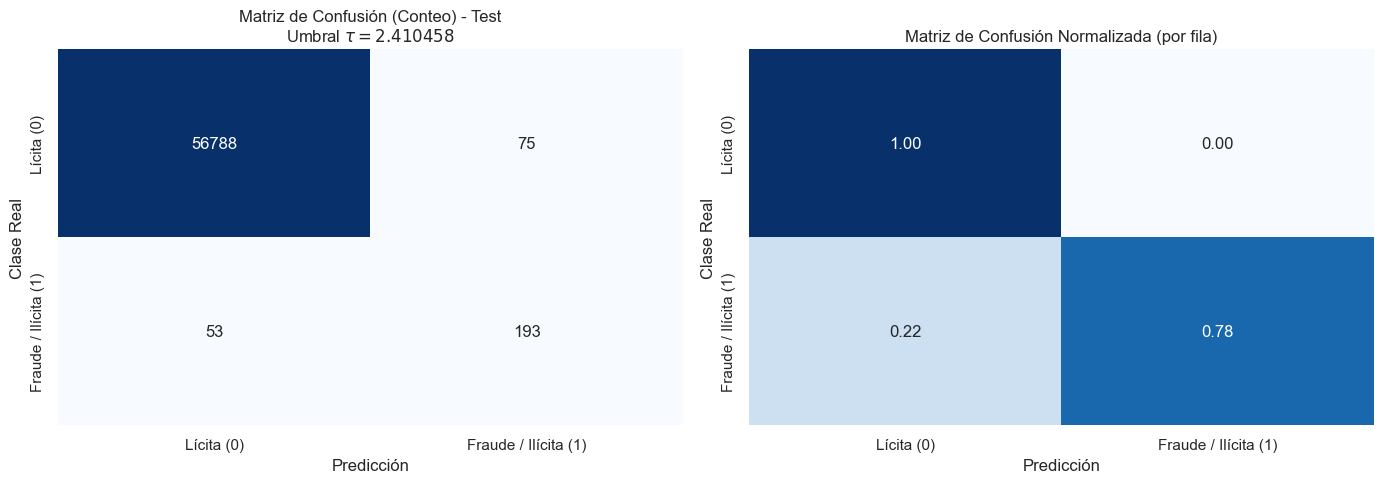


📋 Reporte de Clasificación Detallado en Test:
                      precision    recall  f1-score   support

          Lícita (0)     0.9991    0.9987    0.9989     56863
Ilícita / Fraude (1)     0.7201    0.7846    0.7510       246

            accuracy                         0.9978     57109
           macro avg     0.8596    0.8916    0.8749     57109
        weighted avg     0.9979    0.9978    0.9978     57109

PR-AUC (Average Precision) en Test: 0.7055
ROC-AUC en Test: 0.9465


In [9]:
# ---------------------------------------------------------
# 7. Inferencia y Evaluación Final en TEST SET
# ---------------------------------------------------------
y_pred = (reconstruction_errors_test >= optimal_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Lícita (0)", "Fraude / Ilícita (1)"],
            yticklabels=["Lícita (0)", "Fraude / Ilícita (1)"])
plt.title(f"Matriz de Confusión (Conteo) - Test\nUmbral $\\tau = {optimal_threshold:.6f}$", fontsize=12)
plt.xlabel("Predicción")
plt.ylabel("Clase Real")

plt.subplot(1, 2, 2)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", cbar=False,
            xticklabels=["Lícita (0)", "Fraude / Ilícita (1)"],
            yticklabels=["Lícita (0)", "Fraude / Ilícita (1)"])
plt.title("Matriz de Confusión Normalizada (por fila)", fontsize=12)
plt.xlabel("Predicción")
plt.ylabel("Clase Real")

plt.tight_layout()
plt.show()

avg_prec_test = average_precision_score(y_test, reconstruction_errors_test)

print("\n📋 Reporte de Clasificación Detallado en Test:")
print(classification_report(y_test, y_pred, target_names=["Lícita (0)", "Ilícita / Fraude (1)"], digits=4, zero_division=0))

print(f"PR-AUC (Average Precision) en Test: {avg_prec_test:.4f}")
print(f"ROC-AUC en Test: {roc_auc_test:.4f}")

In [10]:
# ---------------------------------------------------------
# 8. Guardar Artefactos Finales y Configuración
# ---------------------------------------------------------
SEED = 42
threshold_dict = {
    "optimal_threshold": float(optimal_threshold),
    "best_f1_val": float(best_f1),
    "pr_auc_val": float(pr_auc_val),
    "avg_precision_test": float(avg_prec_test),
    "roc_auc_test": float(roc_auc_test),
    "seed": int(SEED)
}

joblib.dump(threshold_dict, PROCESSED_DATA_PATH / "threshold_config.joblib")
np.save(PROCESSED_DATA_PATH / "reconstruction_errors_test.npy", reconstruction_errors_test)
np.save(PROCESSED_DATA_PATH / "y_pred_test.npy", y_pred)

print(f"\n💾 Artefactos guardados exitosamente en: {PROCESSED_DATA_PATH}")
print("   ├─ threshold_config.joblib")
print("   ├─ reconstruction_errors_test.npy")
print("   └─ y_pred_test.npy")


💾 Artefactos guardados exitosamente en: ..\data\processed
   ├─ threshold_config.joblib
   ├─ reconstruction_errors_test.npy
   └─ y_pred_test.npy
